# CNN Benchmark

In [62]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy.io import loadmat
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)
np.random.seed(42)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

device

device(type='mps')

## Load Dataset

In [63]:
mat = loadmat("../../data/driver-drowsiness/cui/dataset.mat")

X_cui_full = mat["EEGsample"].astype(np.float32)      # samples x channels x time
y_cui = mat["substate"].reshape(-1).astype(np.int64)
subjects_cui = mat["subindex"].reshape(-1).astype(np.int64)

label_names = {0: "alert", 1: "drowsy"}

# Keep only the channels shared with Orosco: O1, O2, C3, C4.
cui_channel_names = [
    "Fp1", "Fp2", "F7", "F3", "Fz", "F4", "F8",
    "FT7", "FC3", "FCz", "FC4", "FT8",
    "T3", "C3", "Cz", "C4", "T4",
    "TP7", "CP3", "CPz", "CP4", "TP8",
    "T5", "P3", "Pz", "P4", "T6",
    "O1", "Oz", "O2",
]
shared_channels = ["O1", "O2", "C3", "C4"]
cui_shared_indices = [cui_channel_names.index(channel) for channel in shared_channels]
X_cui = X_cui_full[:, cui_shared_indices, :]

print("Cui full X:", X_cui_full.shape)
print("Cui shared-channel X:", X_cui.shape)
print("Cui y:", y_cui.shape, dict(zip(*np.unique(y_cui, return_counts=True))))
print("Cui subjects:", np.unique(subjects_cui).tolist())


Cui full X: (2022, 30, 384)
Cui shared-channel X: (2022, 4, 384)
Cui y: (2022,) {np.int64(0): np.int64(1011), np.int64(1): np.int64(1011)}
Cui subjects: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]


## Load Orosco Dataset


In [64]:
orosco = np.load("../../data/driver-drowsiness/orosco/dataset/orosco_windowed_balanced.npz", allow_pickle=True)

X_orosco = orosco["X"].astype(np.float32)      # samples x channels x time
y_orosco = orosco["Y"].astype(np.int64)
subjects_orosco = orosco["subjects"].astype(np.int64)

print("Orosco X:", X_orosco.shape)
print("Orosco y:", y_orosco.shape, dict(zip(*np.unique(y_orosco, return_counts=True))))
print("Orosco subjects:", np.unique(subjects_orosco).tolist())
print("Orosco channels:", orosco["channels"].tolist())


Orosco X: (6364, 4, 384)
Orosco y: (6364,) {np.int64(0): np.int64(3182), np.int64(1): np.int64(3182)}
Orosco subjects: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Orosco channels: ['O1-Ref', 'O2-Ref', 'C3-Ref', 'C4-Ref']


## Combine Cui and Orosco


In [65]:
X = np.concatenate([X_cui, X_orosco], axis=0)
y = np.concatenate([y_cui, y_orosco], axis=0)
subjects = np.concatenate([subjects_cui, subjects_orosco], axis=0)
dataset_source = np.concatenate([
    np.full(len(y_cui), "cui"),
    np.full(len(y_orosco), "orosco"),
])

print("Combined X:", X.shape)
print("Combined y:", y.shape, dict(zip(*np.unique(y, return_counts=True))))
print("Combined subjects:", np.unique(subjects).tolist())
print("Dataset counts:", dict(zip(*np.unique(dataset_source, return_counts=True))))
print("Shared channels:", shared_channels)


Combined X: (8386, 4, 384)
Combined y: (8386,) {np.int64(0): np.int64(4193), np.int64(1): np.int64(4193)}
Combined subjects: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
Dataset counts: {np.str_('cui'): np.int64(2022), np.str_('orosco'): np.int64(6364)}
Shared channels: ['O1', 'O2', 'C3', 'C4']


## Subject-Aware Split

This avoids training and testing on windows from the same person. That makes the result a better estimate of whether the model learned EEG state patterns instead of subject identity.

In [66]:
train_subjects = np.arange(1, 9)   # subjects 1-8
val_subjects = np.array([9])       # subject 9
test_subjects = np.array([10, 11]) # subjects 10-11

train_mask = np.isin(subjects, train_subjects)
val_mask = np.isin(subjects, val_subjects)
test_mask = np.isin(subjects, test_subjects)

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

# Normalize using training-set statistics only.
channel_mean = X_train.mean(axis=(0, 2), keepdims=True)
channel_std = X_train.std(axis=(0, 2), keepdims=True) + 1e-6

X_train = (X_train - channel_mean) / channel_std
X_val = (X_val - channel_mean) / channel_std
X_test = (X_test - channel_mean) / channel_std

split_summary = pd.DataFrame({
    "split": ["train", "val", "test"],
    "subjects": [train_subjects.tolist(), val_subjects.tolist(), test_subjects.tolist()],
    "samples": [len(y_train), len(y_val), len(y_test)],
    "alert": [(y_train == 0).sum(), (y_val == 0).sum(), (y_test == 0).sum()],
    "drowsy": [(y_train == 1).sum(), (y_val == 1).sum(), (y_test == 1).sum()],
})

display(split_summary)

,split,subjects,samples,alert,drowsy
0,train,"[1, 2, 3, 4, 5, 6, 7, 8]",6713,2914,3799
1,val,[9],831,646,185
2,test,"[10, 11]",842,633,209


## DataLoaders

In [67]:
batch_size = 32

def make_loader(X_array, y_array, shuffle=False):
    X_tensor = torch.tensor(X_array, dtype=torch.float32)
    y_tensor = torch.tensor(y_array, dtype=torch.long)
    dataset = TensorDataset(X_tensor, y_tensor)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train, y_train, shuffle=True)
val_loader = make_loader(X_val, y_val)
test_loader = make_loader(X_test, y_test)

xb, yb = next(iter(train_loader))
print("batch X:", xb.shape)  # batch x channels x time
print("batch y:", yb.shape)

batch X: torch.Size([32, 4, 384])
batch y: torch.Size([32])


## Basic CNN

This uses the simple pattern:

`conv -> batch norm -> ReLU -> max pool`, repeated three times, then `flatten -> fully connected -> output`.

In [68]:
class BasicEEGCNN(nn.Module):
    def __init__(self, n_channels=30, n_times=384, n_classes=2):
        super().__init__()

        # Edit this block first when experimenting with CNN designs.
        self.conv = nn.Sequential(
            nn.Conv1d(n_channels, 32, kernel_size=7, padding=3),
            nn.ELU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.ELU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(64, 64, kernel_size=3, padding=1),
            nn.ELU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Flatten(),
        )

        with torch.no_grad():
            dummy_input = torch.zeros(1, n_channels, n_times)
            flattened_size = self.conv(dummy_input).shape[1]

        # Edit this block when experimenting with classifier depth/width.
        self.fc = nn.Sequential(
            nn.Linear(flattened_size, 64),
            nn.ELU(),
            nn.Dropout(p=0.3),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        x = self.conv(x)
        return self.fc(x)


model = BasicEEGCNN(n_channels=X_train.shape[1], n_times=X_train.shape[2]).to(device)
model


BasicEEGCNN(
  (conv): Sequential(
    (0): Conv1d(4, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): ELU(alpha=1.0)
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): ELU(alpha=1.0)
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (7): ELU(alpha=1.0)
    (8): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Flatten(start_dim=1, end_dim=-1)
  )
  (fc): Sequential(
    (0): Linear(in_features=3072, out_features=64, bias=True)
    (1): ELU(alpha=1.0)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=2, bias=True)
  )
)

In [69]:
def count_parameters(model):
    return sum(param.numel() for param in model.parameters() if param.requires_grad)


with torch.no_grad():
    logits = model(xb.to(device))

print("input batch:", xb.shape)
print("logits:", logits.shape)
print(f"trainable parameters: {count_parameters(model):,}")


input batch: torch.Size([32, 4, 384])
logits: torch.Size([32, 2])
trainable parameters: 220,386


## Training Utilities

In [70]:
def binary_f1_score(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    f1_scores = []
    for label in [0, 1]:
        tp = np.sum((y_true == label) & (y_pred == label))
        fp = np.sum((y_true != label) & (y_pred == label))
        fn = np.sum((y_true == label) & (y_pred != label))

        precision = tp / (tp + fp + 1e-12)
        recall = tp / (tp + fn + 1e-12)
        f1 = 2 * precision * recall / (precision + recall + 1e-12)
        f1_scores.append(f1)

    return float(np.mean(f1_scores))


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            logits = model(batch_x)
            loss = criterion(logits, batch_y)
            preds = logits.argmax(dim=1)

            total_loss += loss.item() * batch_x.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(batch_y.cpu().numpy())

    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    accuracy = float((all_preds == all_targets).mean())
    f1 = binary_f1_score(all_targets, all_preds)
    avg_loss = total_loss / len(loader.dataset)

    return {"loss": avg_loss, "accuracy": accuracy, "f1_macro": f1}


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0

    for batch_x, batch_y in loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        logits = model(batch_x)
        loss = criterion(logits, batch_y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch_x.size(0)

    return total_loss / len(loader.dataset)

## Train

In [74]:
learning_rate = 1e-3
epochs = 20

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)

history = []
best_val_f1 = -1.0
best_state = None

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer)
    train_metrics = evaluate(model, train_loader, criterion)
    val_metrics = evaluate(model, val_loader, criterion)

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "train_accuracy": train_metrics["accuracy"],
        "train_f1": train_metrics["f1_macro"],
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_f1": val_metrics["f1_macro"],
    }
    history.append(row)

    if val_metrics["f1_macro"] > best_val_f1:
        best_val_f1 = val_metrics["f1_macro"]
        best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}

    print(
        f"epoch {epoch:02d} | "
        f"train loss {train_loss:.4f} acc {train_metrics['accuracy']:.3f} f1 {train_metrics['f1_macro']:.3f} | "
        f"val loss {val_metrics['loss']:.4f} acc {val_metrics['accuracy']:.3f} f1 {val_metrics['f1_macro']:.3f}"
    )

history_df = pd.DataFrame(history)
display(history_df.tail())

epoch 01 | train loss 0.4825 acc 0.789 f1 0.780 | val loss 0.4621 acc 0.838 f1 0.793
epoch 02 | train loss 0.4571 acc 0.816 f1 0.813 | val loss 0.4555 acc 0.826 f1 0.773
epoch 03 | train loss 0.4348 acc 0.823 f1 0.817 | val loss 0.4779 acc 0.805 f1 0.758
epoch 04 | train loss 0.4107 acc 0.849 f1 0.844 | val loss 0.4774 acc 0.791 f1 0.751
epoch 05 | train loss 0.3736 acc 0.884 f1 0.882 | val loss 0.4866 acc 0.768 f1 0.721
epoch 06 | train loss 0.3307 acc 0.900 f1 0.898 | val loss 0.4717 acc 0.798 f1 0.750
epoch 07 | train loss 0.2674 acc 0.949 f1 0.948 | val loss 0.4974 acc 0.785 f1 0.730
epoch 08 | train loss 0.1972 acc 0.972 f1 0.971 | val loss 0.5609 acc 0.770 f1 0.718
epoch 09 | train loss 0.1480 acc 0.974 f1 0.974 | val loss 0.7996 acc 0.696 f1 0.655
epoch 10 | train loss 0.1071 acc 0.986 f1 0.985 | val loss 0.8120 acc 0.718 f1 0.673
epoch 11 | train loss 0.0971 acc 0.983 f1 0.982 | val loss 1.0662 acc 0.670 f1 0.637
epoch 12 | train loss 0.0708 acc 0.994 f1 0.994 | val loss 0.7867

,epoch,train_loss,train_accuracy,train_f1,val_loss,val_accuracy,val_f1
15,16,0.046799,0.983763,0.983399,1.577589,0.625752,0.604180
16,17,0.058945,0.995084,0.995002,0.867062,0.790614,0.731078
17,18,0.060597,0.995978,0.995906,0.982617,0.765343,0.710384
18,19,0.041517,0.998510,0.998484,0.982147,0.740072,0.693136
19,20,0.047317,0.994935,0.994846,1.360027,0.758123,0.700696


## Learning Curves

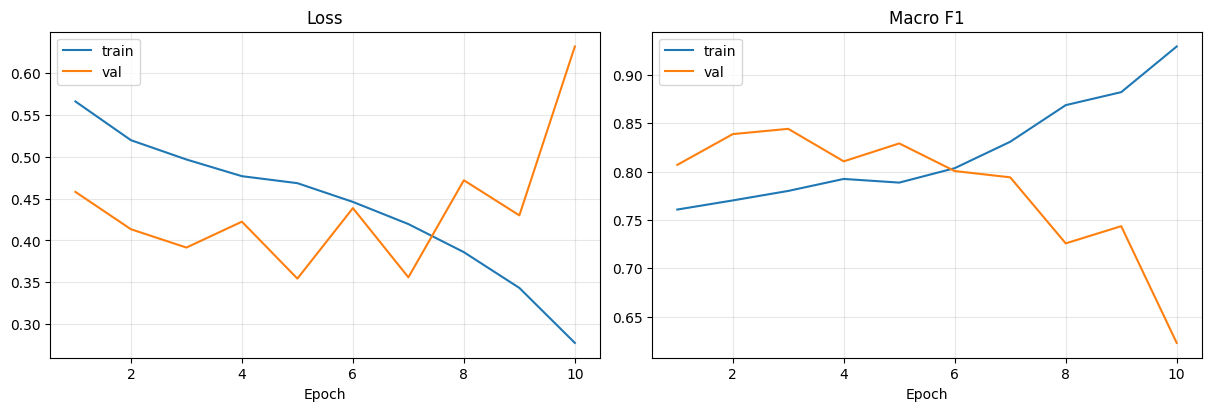

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_df["epoch"], history_df["train_f1"], label="train")
axes[1].plot(history_df["epoch"], history_df["val_f1"], label="val")
axes[1].set_title("Macro F1")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.show()

## Test Set Evaluation

In [73]:
if best_state is not None:
    model.load_state_dict(best_state)
    model.to(device)

test_metrics = evaluate(model, test_loader, criterion)
test_metrics

{'loss': 0.45066111239288315,
 'accuracy': 0.8242280285035629,
 'f1_macro': 0.7674675503999397}